<a href="https://colab.research.google.com/github/Monoartiam99/Project_DA_ML/blob/main/assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
#view the patients csv file
patients = pd.read_csv('patients.csv')
treatments = pd.read_csv('treatments.csv')


In [5]:
patients.head()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [6]:
treatments.head()

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.97
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32


Text(0.5, 1.0, 'Kde plot of all patients of thier weight')

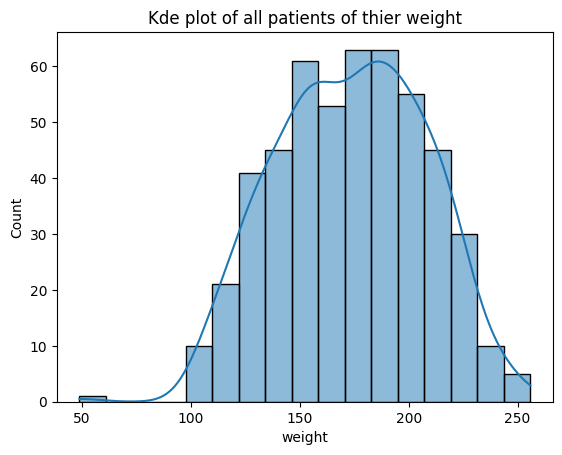

In [7]:
sns.histplot(patients['weight'], kde=True)
plt.title('Kde plot of all patients of thier weight')

Text(0.5, 1.0, 'Kde plot of all patients of thier height')

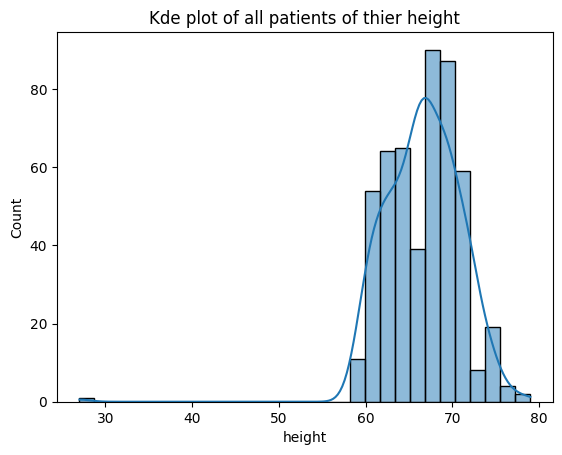

In [8]:
sns.histplot(patients['height'], kde=True)
plt.title('Kde plot of all patients of thier height')

### Preprocessing the data
- Head and tail
- Sample
- info
- isnull
- duplicate
- describe

In [9]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       491 non-null    object 
 5   city          491 non-null    object 
 6   state         491 non-null    object 
 7   zip_code      491 non-null    float64
 8   country       491 non-null    object 
 9   contact       491 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(3), int64(2), object(9)
memory usage: 55.1+ KB


In [10]:
patients.head()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [11]:
patients.tail()

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7
502,503,male,Pat,Gersten,2778 North Avenue,Burr,Nebraska,68324.0,United States,PatrickGersten@rhyta.com402-848-4923,5/3/1954,138.2,71,19.3


In [12]:
patients[patients['address'].isnull()]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
209,210,female,Lalita,Eldarkhanov,NaN,NaN,NaN,NaN,NaN,NaN,8/14/1950,143.4,62,26.2
219,220,male,Mỹ,Quynh,NaN,NaN,NaN,NaN,NaN,NaN,4/9/1978,237.8,69,35.1
230,231,female,Elisabeth,Knudsen,NaN,NaN,NaN,NaN,NaN,NaN,9/23/1976,165.9,63,29.4
234,235,female,Martina,Tománková,NaN,NaN,NaN,NaN,NaN,NaN,4/7/1936,199.5,65,33.2
242,243,male,John,O'Brian,NaN,NaN,NaN,NaN,NaN,NaN,2/25/1957,205.3,74,26.4
249,250,male,Benjamin,Mehler,NaN,NaN,NaN,NaN,NaN,NaN,10/30/1951,146.5,69,21.6
257,258,male,Jin,Kung,NaN,NaN,NaN,NaN,NaN,NaN,5/17/1995,231.7,69,34.2
264,265,female,Wafiyyah,Asfour,NaN,NaN,NaN,NaN,NaN,NaN,11/3/1989,158.6,63,28.1
269,270,female,Flavia,Fiorentino,NaN,NaN,NaN,NaN,NaN,NaN,10/9/1937,175.2,61,33.1
278,279,female,Generosa,Cabán,NaN,NaN,NaN,NaN,NaN,NaN,12/16/1962,124.3,69,18.4


In [13]:
treatments[treatments['auralin'].isnull()]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change


In [14]:
treatments[treatments.duplicated()]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


In [15]:
treatments[treatments.duplicated(subset=['given_name'	,'surname'])]

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
136,joseph,day,29u - 36u,-,7.7,7.19,NaN


In [16]:
patients.describe()

,patient_id,zip_code,weight,height,bmi
count,503.000000,491.000000,503.000000,503.000000,503.000000
mean,252.000000,49084.118126,173.434990,66.634195,27.483897
std,145.347859,30265.807442,33.916741,4.411297,5.276438
min,1.000000,1002.000000,48.800000,27.000000,17.100000
25%,126.500000,21920.500000,149.300000,63.000000,23.300000
50%,252.000000,48057.000000,175.300000,67.000000,27.200000
75%,377.500000,75679.000000,199.500000,70.000000,31.750000
max,503.000000,99701.000000,255.900000,79.000000,37.700000


In [17]:
patients[patients['height']==27]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1


In [18]:
patients[patients['weight']==48.800000]

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
210,211,female,Camilla,Zaitseva,4689 Briarhill Lane,Wooster,OH,44691.0,United States,330-202-2145CamillaZaitseva@superrito.com,11/26/1938,48.8,63,19.1


### Cleaning the data
For cleaning the data we have to follow few steps
1. Quality of completeness
2. Tidiness
3. Quality on the validity
4. Quality on accuracy
5. Quality on Consistency

In [19]:
patients_df = patients.copy()
treatments_df = treatments.copy()

In [20]:
patients_df.fillna('No Data Found', inplace=True)

/tmp/ipykernel_1378/1519890573.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No Data Found' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  patients_df.fillna('No Data Found', inplace=True)


In [21]:
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    503 non-null    int64  
 1   assigned_sex  503 non-null    object 
 2   given_name    503 non-null    object 
 3   surname       503 non-null    object 
 4   address       503 non-null    object 
 5   city          503 non-null    object 
 6   state         503 non-null    object 
 7   zip_code      503 non-null    object 
 8   country       503 non-null    object 
 9   contact       503 non-null    object 
 10  birthdate     503 non-null    object 
 11  weight        503 non-null    float64
 12  height        503 non-null    int64  
 13  bmi           503 non-null    float64
dtypes: float64(2), int64(2), object(10)
memory usage: 55.1+ KB


In [22]:
patients_df

,patient_id,assigned_sex,given_name,surname,address,city,state,zip_code,country,contact,birthdate,weight,height,bmi
0,1,female,Zoe,Wellish,576 Brown Bear Drive,Rancho California,California,92390.0,United States,951-719-9170ZoeWellish@superrito.com,7/10/1976,121.7,66,19.6
1,2,female,Pamela,Hill,2370 University Hill Road,Armstrong,Illinois,61812.0,United States,PamelaSHill@cuvox.de+1 (217) 569-3204,4/3/1967,118.8,66,19.2
2,3,male,Jae,Debord,1493 Poling Farm Road,York,Nebraska,68467.0,United States,402-363-6804JaeMDebord@gustr.com,2/19/1980,177.8,71,24.8
3,4,male,Liêm,Phan,2335 Webster Street,Woodbridge,NJ,7095.0,United States,PhanBaLiem@jourrapide.com+1 (732) 636-8246,7/26/1951,220.9,70,31.7
4,5,male,Tim,Neudorf,1428 Turkey Pen Lane,Dothan,AL,36303.0,United States,334-515-7487TimNeudorf@cuvox.de,2/18/1928,192.3,27,26.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,499,male,Mustafa,Lindström,2530 Victoria Court,Milton Mills,ME,3852.0,United States,207-477-0579MustafaLindstrom@jourrapide.com,4/10/1959,181.1,72,24.6
499,500,male,Ruman,Bisliev,494 Clarksburg Park Road,Sedona,AZ,86341.0,United States,928-284-4492RumanBisliev@gustr.com,3/26/1948,239.6,70,34.4
500,501,female,Jinke,de Keizer,649 Nutter Street,Overland Park,MO,64110.0,United States,816-223-6007JinkedeKeizer@teleworm.us,1/13/1971,171.2,67,26.8
501,502,female,Chidalu,Onyekaozulu,3652 Boone Crockett Lane,Seattle,WA,98109.0,United States,ChidaluOnyekaozulu@jourrapide.com1 360 443 2060,2/13/1952,176.9,67,27.7


In [23]:
selected_data = patients[['patient_id','assigned_sex' ,'given_name','surname', 'birthdate', 'height', 'weight']]

print(selected_data)

     patient_id assigned_sex given_name      surname  birthdate  height  \
0             1       female        Zoe      Wellish  7/10/1976      66   
1             2       female     Pamela         Hill   4/3/1967      66   
2             3         male        Jae       Debord  2/19/1980      71   
3             4         male       Liêm         Phan  7/26/1951      70   
4             5         male        Tim      Neudorf  2/18/1928      27   
..          ...          ...        ...          ...        ...     ...   
498         499         male    Mustafa    Lindström  4/10/1959      72   
499         500         male      Ruman      Bisliev  3/26/1948      70   
500         501       female      Jinke    de Keizer  1/13/1971      67   
501         502       female    Chidalu  Onyekaozulu  2/13/1952      67   
502         503         male        Pat      Gersten   5/3/1954      71   

     weight  
0     121.7  
1     118.8  
2     177.8  
3     220.9  
4     192.3  
..      ...  
4

In [24]:
import re
import numpy as np
import pandas as pd

def find_contact_details(text):
    if pd.isna(text):
        return np.nan, np.nan

    pattern = r"(\+\d{1,3}\s)?(\d{10})"
    match = re.search(pattern, text)

    phone = match.group().strip() if match else np.nan
    email = re.sub(pattern, "", text).strip()

    return phone, email


In [25]:
import re
import pandas as pd

rows = []

for item in patients['contact']:
    phone_match = re.search(
        r'(\d{3}[-.\s]?\d{3}[-.\s]?\d{4}|\(\d{3}\)\s*\d{3}[-.\s]?\d{4}|\d{3}[-.\s]?\d{4})',
        str(item)
    )

    email_match = re.search(
        r'([a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+)',
        str(item)
    )

    phone = phone_match.group(0) if phone_match else None
    email = email_match.group(1) if email_match else None

    rows.append({
        'phone': phone,
        'email': email
    })

df = pd.DataFrame(rows)

print(df)

              phone                                        email
0      951-719-9170         951-719-9170ZoeWellish@superrito.com
1    (217) 569-3204                         PamelaSHill@cuvox.de
2      402-363-6804             402-363-6804JaeMDebord@gustr.com
3    (732) 636-8246                    PhanBaLiem@jourrapide.com
4      334-515-7487              334-515-7487TimNeudorf@cuvox.de
..              ...                                          ...
498    207-477-0579  207-477-0579MustafaLindstrom@jourrapide.com
499    928-284-4492           928-284-4492RumanBisliev@gustr.com
500    816-223-6007        816-223-6007JinkedeKeizer@teleworm.us
501    360 443 2060           ChidaluOnyekaozulu@jourrapide.com1
502    402-848-4923         PatrickGersten@rhyta.com402-848-4923

[503 rows x 2 columns]


In [26]:
import pandas as pd

# extract mobile number
patients['mobile'] = patients['contact'].str.extract(
    r'(\+?\d[\d\s\-\(\)]{8,}\d)'
)

# extract email
patients['email'] = patients['contact'].str.extract(
    r'([a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,})'
)

# create new dataset
new_dataset = patients[
    ['given_name', 'surname', 'mobile', 'email']
]

# save to excel
new_dataset.to_excel("patients_details.xlsx", index=False)

print("Excel file created successfully")

print(new_dataset)

Excel file created successfully
    given_name      surname             mobile  \
0          Zoe      Wellish       951-719-9170   
1       Pamela         Hill  +1 (217) 569-3204   
2          Jae       Debord       402-363-6804   
3         Liêm         Phan  +1 (732) 636-8246   
4          Tim      Neudorf       334-515-7487   
..         ...          ...                ...   
498    Mustafa    Lindström       207-477-0579   
499      Ruman      Bisliev       928-284-4492   
500      Jinke    de Keizer       816-223-6007   
501    Chidalu  Onyekaozulu     1 360 443 2060   
502        Pat      Gersten       402-848-4923   

                                           email  
0           951-719-9170ZoeWellish@superrito.com  
1                           PamelaSHill@cuvox.de  
2               402-363-6804JaeMDebord@gustr.com  
3                      PhanBaLiem@jourrapide.com  
4                334-515-7487TimNeudorf@cuvox.de  
..                                           ...  
498  207-4

### data cleaning of the treatment dataset

In [27]:
treatments_df

,given_name,surname,auralin,novodra,hba1c_start,hba1c_end,hba1c_change
0,veronika,jindrová,41u - 48u,-,7.63,7.20,NaN
1,elliot,richardson,-,40u - 45u,7.56,7.09,0.97
2,yukitaka,takenaka,-,39u - 36u,7.68,7.25,NaN
3,skye,gormanston,33u - 36u,-,7.97,7.62,0.35
4,alissa,montez,-,33u - 29u,7.78,7.46,0.32
...,...,...,...,...,...,...,...
275,albina,zetticci,45u - 51u,-,7.93,7.73,0.20
276,john,teichelmann,-,49u - 49u,7.90,7.58,NaN
277,mathea,lillebø,23u - 36u,-,9.04,8.67,0.37
278,vallie,prince,31u - 38u,-,7.64,7.28,0.36


In [28]:
treatments_df = treatments_df.melt(id_vars=['given_name', 'surname' ,'hba1c_start', 'hba1c_end','hba1c_change'],var_name='type',value_name='dosage_range')

In [29]:
treatments_df = treatments_df[treatments_df['dosage_range'] != '-']

In [30]:
treatments_df['dosage_start'] = treatments_df['dosage_range'].str.split('-').str.get(0)
treatments_df['dosage_end'] = treatments_df['dosage_range'].str.split('-').str.get(1)

In [31]:
treatments_df.drop(columns='dosage_range',inplace=True)

In [32]:
treatments_df['dosage_start'] = treatments_df['dosage_start'].str.replace('u','')
treatments_df['dosage_end'] = treatments_df['dosage_end'].str.replace('u','')

In [33]:
treatments_df['dosage_start'] = treatments_df['dosage_start'].astype('int')
treatments_df['dosage_end'] = treatments_df['dosage_end'].astype('int')

In [34]:
treatments_df

,given_name,surname,hba1c_start,hba1c_end,hba1c_change,type,dosage_start,dosage_end
0,veronika,jindrová,7.63,7.20,NaN,auralin,41,48
3,skye,gormanston,7.97,7.62,0.35,auralin,33,36
6,sophia,haugen,7.65,7.27,0.38,auralin,37,42
7,eddie,archer,7.89,7.55,0.34,auralin,31,38
9,asia,woźniak,7.76,7.37,NaN,auralin,30,36
...,...,...,...,...,...,...,...,...
548,yasmin,araujo,7.82,7.36,0.96,novodra,51,54
549,hiromu,horikawa,7.77,7.28,NaN,novodra,47,46
551,leo,vieira,7.74,7.36,NaN,novodra,30,33
552,steven,roy,7.87,7.43,0.94,novodra,41,43


<Axes: xlabel='type', ylabel='dosage_start'>

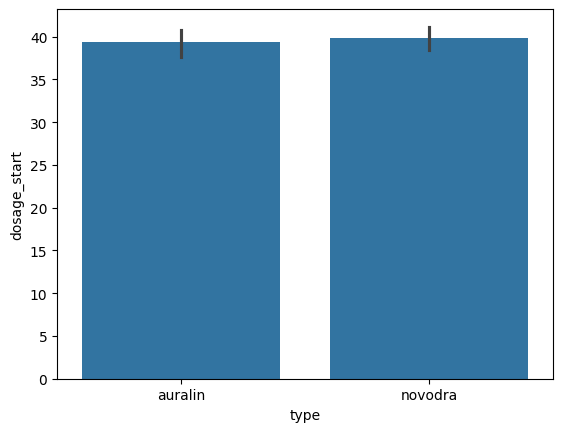

In [35]:
sns.barplot(x='type',y='dosage_start',data=treatments_df)

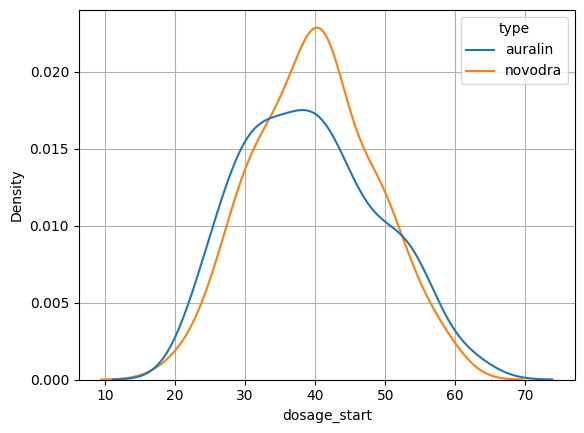

In [36]:
sns.kdeplot(data=treatments_df,x='dosage_start',hue='type')
plt.grid(True)

# My First ML Model

In [37]:
#Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Example: Predict 'weight' based on 'height'
X = patients[['height']]
y = patients['weight']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [38]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

In [39]:
y_lr_train_pred

array([155.53129682, 181.09172955, 160.17864823, 178.76805385,
       160.17864823, 169.47335104, 178.76805385, 174.12070244,
       155.53129682, 157.85497252, 174.12070244, 174.12070244,
       174.12070244, 183.41540526, 178.76805385, 167.14967534,
       199.68113518, 174.12070244, 160.17864823, 185.73908096,
       169.47335104, 176.44437815, 176.44437815, 176.44437815,
       162.50232393, 178.76805385, 178.76805385, 176.44437815,
       162.50232393, 181.09172955, 164.82599963, 185.73908096,
       157.85497252, 185.73908096, 157.85497252, 164.82599963,
       174.12070244, 157.85497252, 160.17864823, 174.12070244,
       162.50232393, 169.47335104, 157.85497252, 188.06275666,
       174.12070244, 171.79702674, 164.82599963, 176.44437815,
       167.14967534, 181.09172955, 178.76805385, 164.82599963,
       160.17864823, 174.12070244, 164.82599963, 181.09172955,
       190.38643236, 181.09172955, 174.12070244, 176.44437815,
       169.47335104, 181.09172955, 174.12070244, 181.09

In [40]:
y_lr_test_pred

array([155.53129682, 176.44437815, 167.14967534, 171.79702674,
       162.50232393, 174.12070244, 174.12070244, 178.76805385,
       164.82599963, 185.73908096, 167.14967534, 174.12070244,
       174.12070244, 164.82599963, 171.79702674, 174.12070244,
       185.73908096, 169.47335104, 164.82599963, 169.47335104,
       176.44437815, 174.12070244, 162.50232393, 157.85497252,
       164.82599963, 178.76805385, 169.47335104, 169.47335104,
       185.73908096, 155.53129682, 164.82599963, 176.44437815,
       164.82599963, 178.76805385, 183.41540526, 169.47335104,
       157.85497252, 176.44437815, 164.82599963, 185.73908096,
       164.82599963, 183.41540526, 174.12070244, 167.14967534,
       185.73908096, 171.79702674, 171.79702674, 188.06275666,
       178.76805385, 169.47335104, 169.47335104, 178.76805385,
       167.14967534, 181.09172955, 181.09172955, 185.73908096,
       174.12070244, 167.14967534, 178.76805385, 178.76805385,
       185.73908096, 160.17864823, 185.73908096, 190.38

In [41]:
import numpy as np


treatments["auralin_used"] = treatments["auralin"].apply(lambda x: 0 if x == "-" else 1)
treatments["novodra_used"] = treatments["novodra"].apply(lambda x: 0 if x == "-" else 1)


treatments = treatments.dropna(subset=["hba1c_end"])

In [42]:
X = treatments[["hba1c_start", "auralin_used", "novodra_used"]]
y = treatments["hba1c_end"]

In [43]:
#train / test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
#first model build
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
from sklearn.metrics import mean_absolute_error, r2_score

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.0429537342787007
R2 Score: 0.988960663668289


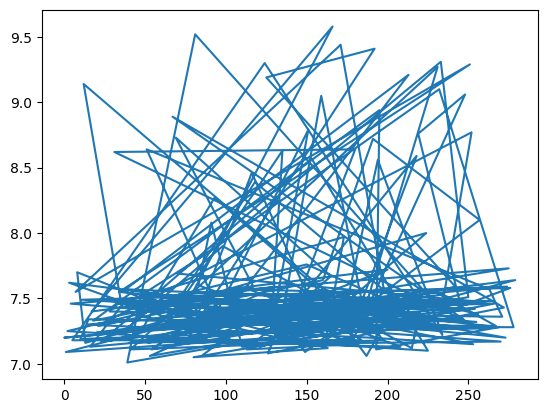

In [46]:
plt.plot(y_train)

### Feature Engineering
1. Current features
- hba1c_start
- auralin_used
- novodra_used

In [47]:
def treatment_type(row):
    if row["auralin_used"] == 1 and row["novodra_used"] == 0:
        return 1
    elif row["auralin_used"] == 0 and row["novodra_used"] == 1:
        return 2
    elif row["auralin_used"] == 1 and row["novodra_used"] == 1:
        return 3
    else:
        return 0

treatments["treatment_type"] = treatments.apply(treatment_type, axis=1)

In [48]:
treatments["auralin_effect"] = treatments["hba1c_start"] * treatments["auralin_used"]
treatments["novodra_effect"] = treatments["hba1c_start"] * treatments["novodra_used"]

In [49]:
treatments["hba1c_start_sq"] = treatments["hba1c_start"] ** 2

In [50]:
#Model-1
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

pred1 = lr.predict(X_test)

mae1 = mean_absolute_error(y_test, pred1)
r21 = r2_score(y_test, pred1)

print("Linear Regression")
print("MAE:", mae1)
print("R2:", r21)

Linear Regression
MAE: 0.0429537342787007
R2: 0.988960663668289


In [51]:
#model -2
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred2 = rf.predict(X_test)

mae2 = mean_absolute_error(y_test, pred2)
r22 = r2_score(y_test, pred2)

print("Random Forest")
print("MAE:", mae2)
print("R2:", r22)

Random Forest
MAE: 0.060559886750152905
R2: 0.9808660426147473


In [52]:
#Comaprison Model
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae1, mae2],
    "R2 Score": [r21, r22]
})

print(comparison)

               Model       MAE  R2 Score
0  Linear Regression  0.042954  0.988961
1      Random Forest  0.060560  0.980866


In [53]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

hba1c_start     0.998182
auralin_used    0.000938
novodra_used    0.000880
dtype: float64
